# 05 No supervisado

Busco grupos de estudiantes sin usar `objetivo` para entrenar.


In [1]:
from pathlib import Path
import sys
import os
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 1)

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocess_base import (
    cargar_data,
    limpieza_basica,
    permutar_filas,
    tratar_ceros_notas_sin_evaluacion,
)
from src.preprocess_no_supervisado import get_unsupervised_dataset
from src.utils import PROJECT_PALETTE, adaptar_dataframe_a_sklearn, annotate_bars, set_project_style
from src.validacion_cruzada_propia import cross_validation_clustering

warnings.filterwarnings("ignore", message="Found unknown categories in columns")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")
pd.set_option("display.max_columns", None)
set_project_style()
print("Proyecto:", PROJECT_ROOT.name)


Proyecto: student-academic-performance


## Planteamiento

- No uso `objetivo` para crear clusters.
- Comparo variables de entrada contra entrada + primer semestre.
- Uso PCA para reducir dimension y KMeans para agrupar.
- Despues miro como quedan los grupos.


In [2]:
RANDOM_STATE = 42
CV_FOLDS = 5
PCA_VARIANCE_TO_KEEP = 0.85
PCA_VARIANCE_GRID = [0.80, 0.85, 0.90, 0.95]
PCA_SENSITIVITY_K_RANGE = [2, 3, 4]
UNKNOWN_AS_MISSING = False
PROFILE_COMPARISON_K_RANGE = [2, 3, 4, 5]
K_RANGE = list(range(2, 9))
STABILITY_SEEDS = [0, 1, 2, 3, 4]


def build_unsupervised_preprocessor(X):
    numeric_cols = X.select_dtypes(include="number").columns.tolist()
    categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )
    return preprocessor, numeric_cols, categorical_cols


def prepare_unsupervised_data(profile):
    df = cargar_data()
    df = permutar_filas(df, random_state=RANDOM_STATE)
    df = limpieza_basica(df, desconocido_es_nan=UNKNOWN_AS_MISSING)
    df = tratar_ceros_notas_sin_evaluacion(df)
    df = df.convert_dtypes()

    df_original = df.copy()
    df_model = adaptar_dataframe_a_sklearn(df)
    X = get_unsupervised_dataset(df_model, profile=profile)
    objetivo = df_original["objetivo"].copy()
    preprocessor, numeric_cols, categorical_cols = build_unsupervised_preprocessor(X)

    return df_original, X, objetivo, preprocessor, numeric_cols, categorical_cols


def mean_pairwise_ari(labels_list):
    scores = [adjusted_rand_score(a, b) for a, b in combinations(labels_list, 2)]
    return float(np.mean(scores)), scores


def resumen_categorias_dominantes(df, cluster_col, columns):
    rows = []
    for cluster in sorted(df[cluster_col].unique()):
        sub = df[df[cluster_col] == cluster]
        for col in columns:
            valid = sub[col].dropna()
            if valid.empty:
                resumen = np.nan
            else:
                moda = valid.mode().iloc[0]
                pct = (valid == moda).mean() * 100
                resumen = f"{moda} ({pct:.1f}%)"
            rows.append({"cluster": cluster, "variable": col, "resumen": resumen})
    return pd.DataFrame(rows).pivot(index="cluster", columns="variable", values="resumen")


## Perfil `entry` vs `sem1`

Comparo si salen grupos mas claros usando solo datos de entrada o anadiendo el primer semestre.


,profile,mejor_k_en_rango_reducido,mejor_cv_silhouette,n_features_originales,n_numericas,n_categoricas
1,sem1,2,0.342,30,13,17
0,entry,2,0.136,24,7,17


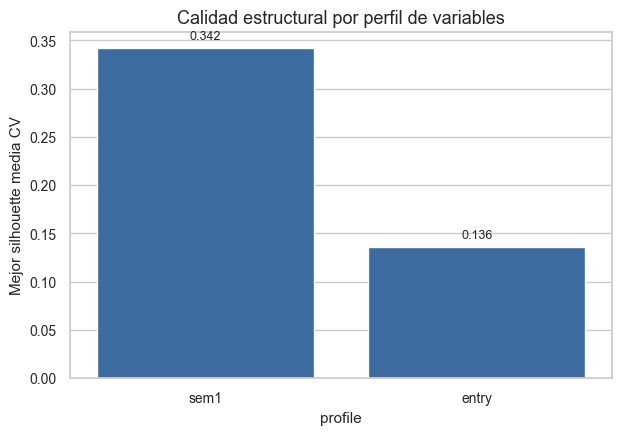

In [3]:
profile_rows = []

for profile in ["entry", "sem1"]:
    df_original, X, objetivo, preprocessor, numeric_cols, categorical_cols = prepare_unsupervised_data(profile)

    best_mean = -np.inf
    best_k = None
    for k in PROFILE_COMPARISON_K_RANGE:
        _, summary = cross_validation_clustering(
            X=X,
            preprocessor=preprocessor,
            n_clusters=k,
            n_folds=CV_FOLDS,
            pca_variance_to_keep=PCA_VARIANCE_TO_KEEP,
            random_state=RANDOM_STATE,
        )
        score = summary.loc[0, "mean"]
        if score > best_mean:
            best_mean = score
            best_k = k

    profile_rows.append(
        {
            "profile": profile,
            "mejor_k_en_rango_reducido": best_k,
            "mejor_cv_silhouette": best_mean,
            "n_features_originales": X.shape[1],
            "n_numericas": len(numeric_cols),
            "n_categoricas": len(categorical_cols),
        }
    )

df_profile_compare = pd.DataFrame(profile_rows).sort_values("mejor_cv_silhouette", ascending=False)
display(df_profile_compare.round(3))

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(
    data=df_profile_compare,
    x="profile",
    y="mejor_cv_silhouette",
    color=PROJECT_PALETTE["primary"],
)
ax.set_title("Calidad estructural por perfil de variables")
ax.set_ylabel("Mejor silhouette media CV")
annotate_bars(ax)
plt.show()


## Decision

Me quedo con `sem1`. Da una estructura mas clara, aunque no significa que los grupos sean perfectos.


Profile elegido: sem1
X original: (4424, 30)
X preparado: (4424, 230)
Variables numericas: 13
Variables categoricas: 17
Componentes necesarios para conservar 0.85 : 26


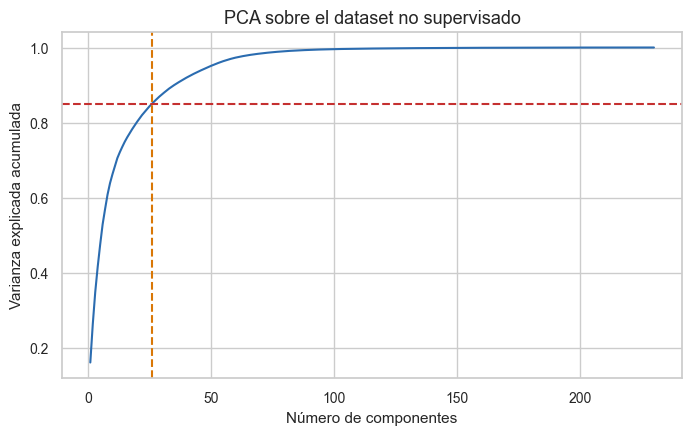

In [4]:
PROFILE = "sem1"
df_original, X, objetivo, preprocessor, numeric_cols, categorical_cols = prepare_unsupervised_data(PROFILE)

X_prepared = preprocessor.fit_transform(X)
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_prepared)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_keep = int(np.searchsorted(cum_var, PCA_VARIANCE_TO_KEEP) + 1)

print("Profile elegido:", PROFILE)
print("X original:", X.shape)
print("X preparado:", X_prepared.shape)
print("Variables numericas:", len(numeric_cols))
print("Variables categoricas:", len(categorical_cols))
print("Componentes necesarios para conservar", PCA_VARIANCE_TO_KEEP, ":", n_components_keep)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum_var) + 1), cum_var, color=PROJECT_PALETTE["primary"])
plt.axhline(PCA_VARIANCE_TO_KEEP, linestyle="--", color=PROJECT_PALETTE["danger"])
plt.axvline(n_components_keep, linestyle="--", color=PROJECT_PALETTE["accent"])
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA sobre el dataset no supervisado")
plt.show()


## Elegir k

Pruebo varios valores de `k` y miro silhouette media en validacion.


Mejor k por silhouette media CV: 2


,k,cv_silhouette_mean,cv_silhouette_std,valid_folds
0,2,0.342,0.012,5
1,3,0.173,0.005,5
6,8,0.118,0.005,5
4,6,0.111,0.003,5
5,7,0.110,0.004,5
3,5,0.105,0.006,5
2,4,0.094,0.009,5


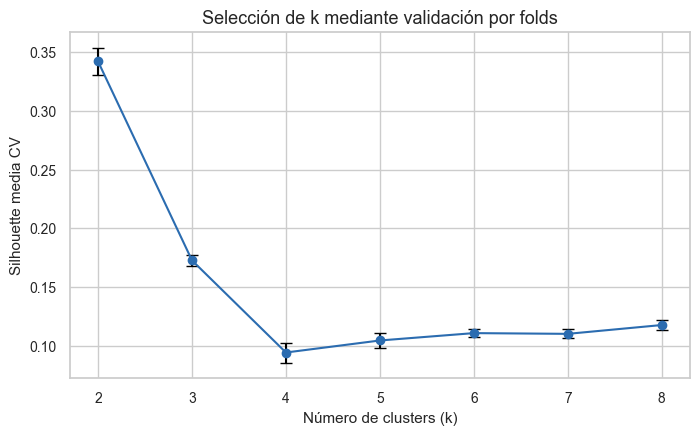

In [5]:
resultados_cv = []

for k in K_RANGE:
    _, summary = cross_validation_clustering(
        X=X,
        preprocessor=preprocessor,
        n_clusters=k,
        n_folds=CV_FOLDS,
        pca_variance_to_keep=PCA_VARIANCE_TO_KEEP,
        random_state=RANDOM_STATE,
    )
    resultados_cv.append(
        {
            "k": k,
            "cv_silhouette_mean": summary.loc[0, "mean"],
            "cv_silhouette_std": summary.loc[0, "std"],
            "valid_folds": summary.loc[0, "valid_folds"],
        }
    )

df_cv_kmeans = pd.DataFrame(resultados_cv).sort_values("k")
best_k = int(df_cv_kmeans.sort_values("cv_silhouette_mean", ascending=False).iloc[0]["k"])
display(df_cv_kmeans.sort_values("cv_silhouette_mean", ascending=False).round(3))

plt.figure(figsize=(8, 4.5))
plt.errorbar(
    df_cv_kmeans["k"],
    df_cv_kmeans["cv_silhouette_mean"],
    yerr=df_cv_kmeans["cv_silhouette_std"],
    marker="o",
    color=PROJECT_PALETTE["primary"],
    ecolor="black",
    capsize=4,
)
plt.title("Selección de k mediante validación por folds")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette media CV")
plt.show()

print("Mejor k por silhouette media CV:", best_k)


## Sensibilidad a PCA

Tambien miro si cambia la conclusion al conservar distinta varianza en PCA.


k,2,3,4
pca_variance,,,
0.80,0.357,0.184,0.107
0.85,0.342,0.173,0.094
0.90,0.330,0.164,0.091
0.95,0.317,0.156,0.086


,pca_variance,k,cv_silhouette_mean,cv_silhouette_std,valid_folds
0,0.80,2,0.357,0.012,5
1,0.85,2,0.342,0.012,5
2,0.90,2,0.330,0.012,5
3,0.95,2,0.317,0.011,5


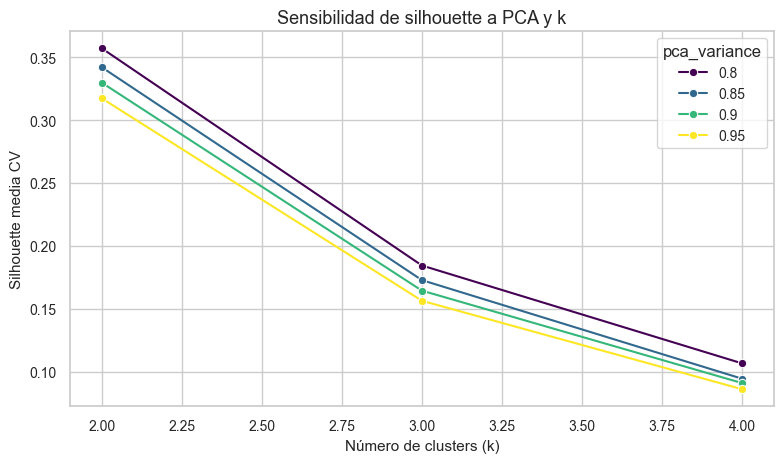

In [6]:
pca_sensitivity_rows = []

for pca_keep in PCA_VARIANCE_GRID:
    for k in PCA_SENSITIVITY_K_RANGE:
        _, summary = cross_validation_clustering(
            X=X,
            preprocessor=preprocessor,
            n_clusters=k,
            n_folds=CV_FOLDS,
            pca_variance_to_keep=pca_keep,
            random_state=RANDOM_STATE,
        )
        pca_sensitivity_rows.append(
            {
                "pca_variance": pca_keep,
                "k": k,
                "cv_silhouette_mean": summary.loc[0, "mean"],
                "cv_silhouette_std": summary.loc[0, "std"],
                "valid_folds": summary.loc[0, "valid_folds"],
            }
        )

df_pca_sensitivity = pd.DataFrame(pca_sensitivity_rows)
display(
    df_pca_sensitivity
    .pivot(index="pca_variance", columns="k", values="cv_silhouette_mean")
    .round(3)
)

df_best_by_pca = (
    df_pca_sensitivity
    .sort_values(["pca_variance", "cv_silhouette_mean"], ascending=[True, False])
    .groupby("pca_variance")
    .head(1)
    .reset_index(drop=True)
)
display(df_best_by_pca.round(3))

plt.figure(figsize=(8, 4.8))
sns.lineplot(
    data=df_pca_sensitivity,
    x="k",
    y="cv_silhouette_mean",
    hue="pca_variance",
    marker="o",
    palette="viridis",
)
plt.title("Sensibilidad de silhouette a PCA y k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette media CV")
plt.tight_layout()
plt.show()


### Lectura

Si `k=2` sigue saliendo bien al cambiar PCA, la decision es mas estable. Aun asi, una silhouette cerca de 0.34 indica separacion moderada.


## Ajuste final

Ajusto KMeans con el `k` elegido y describo los clusters.


Silhouette final sobre todo el dataset: 0.3414
ARI medio entre semillas: 1.0
ARIs individuales: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


,n_estudiantes
cluster,
0,300
1,4124


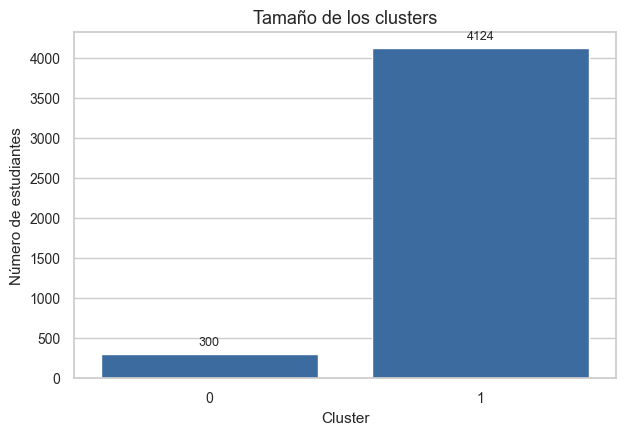

In [7]:
pca_final = PCA(n_components=PCA_VARIANCE_TO_KEEP, svd_solver="full", random_state=RANDOM_STATE)
X_cluster = pca_final.fit_transform(X_prepared)

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
clusters = kmeans_final.fit_predict(X_cluster)
silhouette_final = silhouette_score(X_cluster, clusters)

df_analysis = df_original.copy()
df_analysis["cluster"] = clusters
df_analysis["objetivo"] = objetivo.values

cluster_sizes = df_analysis["cluster"].value_counts().sort_index().rename("n_estudiantes").to_frame()
display(cluster_sizes)
print("Silhouette final sobre todo el dataset:", round(silhouette_final, 4))

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(
    x=cluster_sizes.index.astype(str),
    y=cluster_sizes["n_estudiantes"].values,
    color=PROJECT_PALETTE["primary"],
)
ax.set_title("Tamaño de los clusters")
ax.set_xlabel("Cluster")
ax.set_ylabel("Número de estudiantes")
annotate_bars(ax, decimals=0)
plt.show()

labels_by_seed = []
for seed in STABILITY_SEEDS:
    labels_seed = KMeans(n_clusters=best_k, random_state=seed, n_init=20).fit_predict(X_cluster)
    labels_by_seed.append(labels_seed)

mean_ari, ari_scores = mean_pairwise_ari(labels_by_seed)
print("ARI medio entre semillas:", round(mean_ari, 4))
print("ARIs individuales:", [round(x, 4) for x in ari_scores])


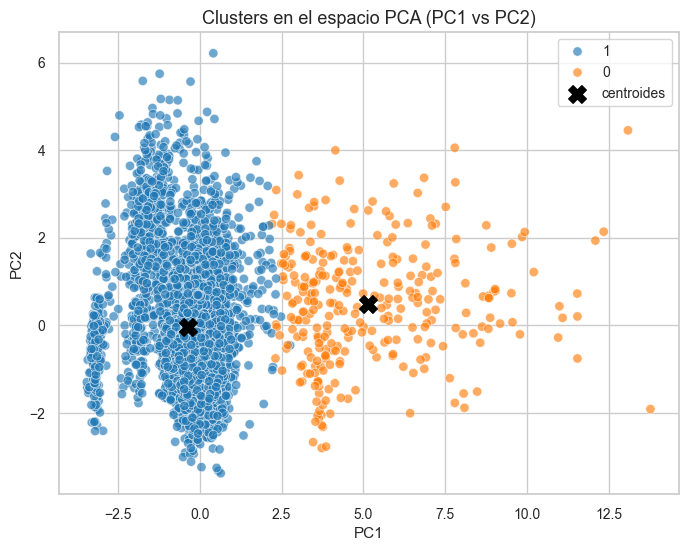

In [8]:
plot_df = pd.DataFrame(
    {
        "PC1": X_cluster[:, 0],
        "PC2": X_cluster[:, 1],
        "cluster": clusters.astype(str),
    }
)
centroids = pd.DataFrame(kmeans_final.cluster_centers_[:, :2], columns=["PC1", "PC2"])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.65,
    s=45,
)
plt.scatter(
    centroids["PC1"],
    centroids["PC2"],
    c="black",
    s=160,
    marker="X",
    label="centroides",
)
plt.title("Clusters en el espacio PCA (PC1 vs PC2)")
plt.legend()
plt.show()


objetivo,abandono,graduado,matriculado
cluster,,,
0,0.243,0.627,0.130
1,0.327,0.490,0.183


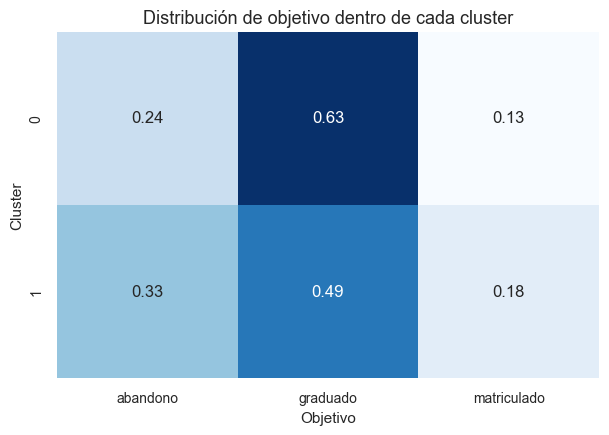

In [9]:
distribucion_objetivo = pd.crosstab(
    df_analysis["cluster"],
    df_analysis["objetivo"],
    normalize="index",
).round(3)
display(distribucion_objetivo)

plt.figure(figsize=(7, 4.5))
sns.heatmap(
    distribucion_objetivo,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
)
plt.title("Distribución de objetivo dentro de cada cluster")
plt.xlabel("Objetivo")
plt.ylabel("Cluster")
plt.show()


,edad_al_matricularse,nota_cualificacion_previa,nota_admision,orden_solicitud,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion
cluster,,,,,,,,,
0,29.37,131.56,129.22,1.14,12.96,16.52,11.35,12.61,0.43
1,22.82,132.69,126.82,1.77,5.78,7.7,4.22,11.47,0.12


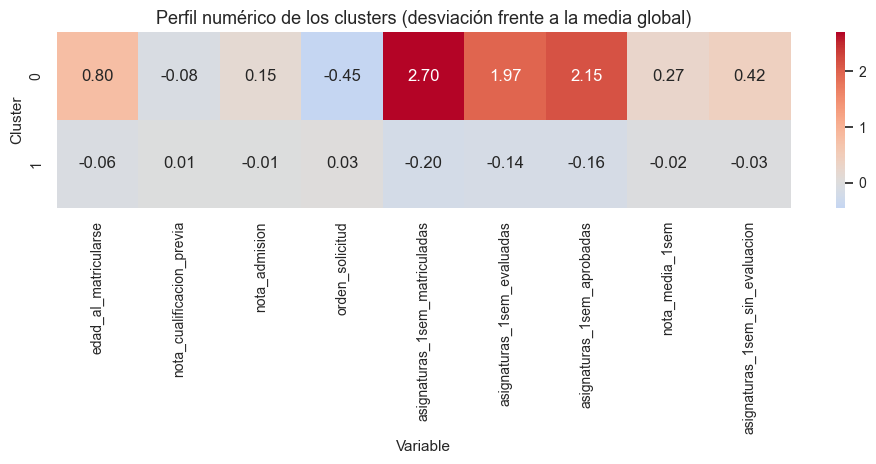

variable,asistencia_diurna_vespertina,becado,desplazado,deudor,genero,internacional,matricula_al_dia
cluster,,,,,,,
0,diurna (72.3%),no (88.3%),no (60.7%),no (84.7%),mujer (63.7%),no (97.3%),si (89.3%)
1,diurna (90.3%),no (74.2%),si (56.0%),no (88.9%),mujer (64.9%),no (97.5%),si (88.0%)


In [10]:
perfil_cols = [
    "edad_al_matricularse",
    "nota_cualificacion_previa",
    "nota_admision",
    "orden_solicitud",
    "asignaturas_1sem_matriculadas",
    "asignaturas_1sem_evaluadas",
    "asignaturas_1sem_aprobadas",
    "nota_media_1sem",
    "asignaturas_1sem_sin_evaluacion",
]
perfil_cols = [col for col in perfil_cols if col in df_analysis.columns]

perfil_numerico = df_analysis.groupby("cluster")[perfil_cols].mean()
perfil_z = ((perfil_numerico - df_analysis[perfil_cols].mean()) / df_analysis[perfil_cols].std()).astype(float)
display(perfil_numerico.round(2))

plt.figure(figsize=(10, 4.8))
sns.heatmap(perfil_z, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Perfil numérico de los clusters (desviación frente a la media global)")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

categorical_profile_cols = [
    "becado",
    "deudor",
    "matricula_al_dia",
    "desplazado",
    "genero",
    "internacional",
    "asistencia_diurna_vespertina",
]
categorical_profile_cols = [col for col in categorical_profile_cols if col in df_analysis.columns]
display(resumen_categorias_dominantes(df_analysis, "cluster", categorical_profile_cols))


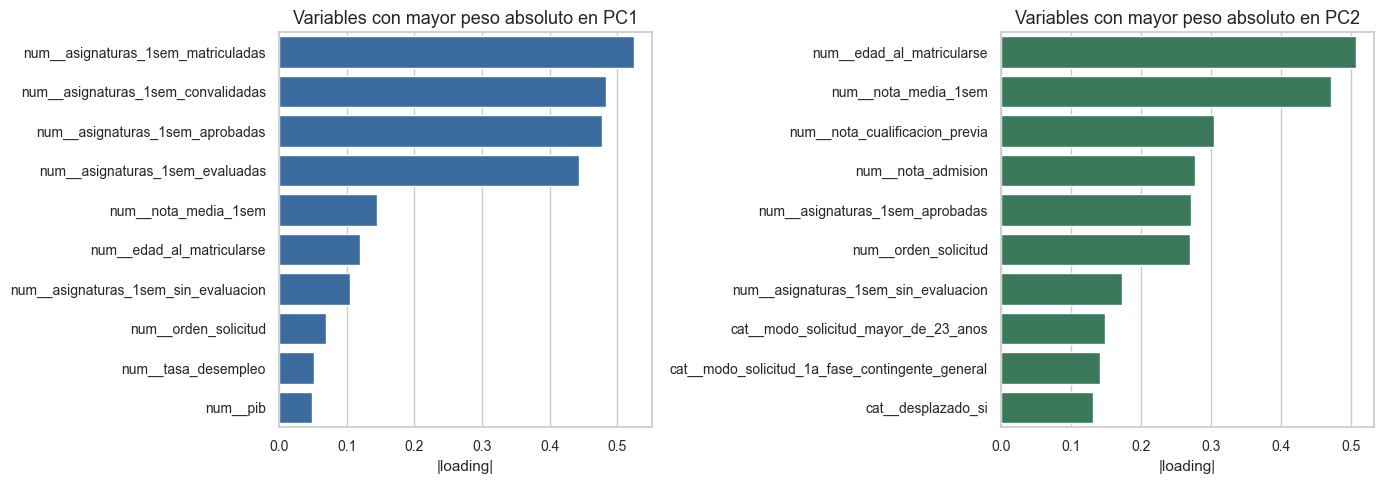

In [11]:
feature_names = preprocessor.get_feature_names_out()
loadings = pd.DataFrame(
    pca_final.components_[:2].T,
    index=feature_names,
    columns=["PC1", "PC2"],
)

top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    x=top_pc1.values,
    y=top_pc1.index,
    color=PROJECT_PALETTE["primary"],
    ax=axes[0],
)
axes[0].set_title("Variables con mayor peso absoluto en PC1")
axes[0].set_xlabel("|loading|")
axes[0].set_ylabel("")

sns.barplot(
    x=top_pc2.values,
    y=top_pc2.index,
    color=PROJECT_PALETTE["secondary"],
    ax=axes[1],
)
axes[1].set_title("Variables con mayor peso absoluto en PC2")
axes[1].set_xlabel("|loading|")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


In [12]:
resumen_final_clusters = pd.DataFrame(
    [
        {
            "profile": PROFILE,
            "k_elegido": best_k,
            "silhouette_final": silhouette_final,
            "ari_medio_semillas": mean_ari,
            "lectura": "separacion moderada",
        }
    ]
)

display(resumen_final_clusters.round(3))
print("Uso de los clusters: descripcion de perfiles, no prediccion de objetivo")


Uso de los clusters: descripcion de perfiles, no prediccion de objetivo


,profile,k_elegido,silhouette_final,ari_medio_semillas,lectura
0,sem1,2,0.341,1.0,separacion moderada


## Conclusiones

- `sem1` da grupos mas claros que `entry`.
- El mejor `k` es 2 en esta configuracion.
- La separacion es moderada, no muy fuerte.
- Los clusters no copian `objetivo`; sirven como perfil descriptivo.
- Aparece un grupo pequeno con estudiantes de mayor edad y mas presencia vespertina.


## Exportar resultados

Tablas reproducibles para el resumen del repositorio.

In [13]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
resumen_final_clusters.to_csv(RESULTS_DIR / "clustering_summary.csv", index=False)
df_cv_kmeans.to_csv(RESULTS_DIR / "clustering_cv.csv", index=False)
